# Domain architecture by function — Pfam atlas on Ensembl r115

This notebook builds the manuscript's functional-architecture analyses directly
from a current annotation (Ensembl release 115), so every number is reproducible
end to end:

1. **Exons per domain, by function** — what fraction of each functional class is
   encoded by a single exon (Fig. 1D).
2. **Position of the domain in the transcript** — where domains sit along the
   5′→3′ exon order.
3. **Completeness** — what fraction of the nucleotides of the exons a domain
   touches actually code that domain.

Every Pfam-A instance on the **canonical isoform of each gene** is mapped with
`prot2exon`, and the per-domain exon structure is summarised (we pull all
isoforms from BioMart, then keep one representative per gene so a domain is not
counted once per splice variant). The heavy steps are **cache-aware**:
if the prepared file is already on disk they are skipped, so a re-run is fast.

### Inputs (all prepared below if missing)

| File | Source |
|---|---|
| `pfam_human_v115_meta.tsv` / `.bed` | Ensembl BioMart (release 115): ENSP + Pfam accession + aa range |
| `human_v115.idx` | `prot2exon index` on the release-115 GTF |
| `pfam2go.txt` | GO `external2go/pfam2go` — Pfam → GO, used for functional class |

In [1]:
# Force the inline backend — under `jupyter nbconvert --execute` the
# default sometimes lands on Agg, which prints `<Figure …>` instead of
# the actual PNG. The magic call forces module://matplotlib_inline.backend_inline.
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    pass  # Not in IPython (e.g. plain python REPL); ignore.
import matplotlib as mpl
import matplotlib.pyplot as plt

# Paper-ready figure defaults. Tweaks vs matplotlib's stock style:
#   - Larger fonts (10pt body, 11pt axis labels, 12pt title).
#   - Thinner spines + only-left/-bottom by default (less chartjunk).
#   - Subtle horizontal grid; no vertical grid.
#   - tab10 palette but used sparingly — we override per-plot.
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 200,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'semibold',
    'axes.titlepad': 10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    0.8,
    'axes.grid': True,
    'axes.grid.axis': 'y',
    'grid.color': '#e5e7eb',
    'grid.linewidth': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'legend.frameon': False,
    'legend.fontsize': 10,
    'lines.linewidth': 2.0,
})

# Colorblind-safe palette (Wong 2011, also used in seaborn's 'colorblind').
COLORS = {
    'prot2exon':   '#0072B2',  # blue
    'ensembldb':   '#009E73',  # bluish green
    'transvar':    '#E69F00',  # orange
    'rest':        '#CC79A7',  # reddish-purple
    'good':        '#009E73',
    'bad':         '#D55E00',  # vermilion (works for colorblind)
    'neutral':     '#56B4E9',
    'highlight':   '#F0E442',
}

import os, sys, subprocess, pickle, re, urllib.parse, urllib.request, time
from pathlib import Path
import pandas as pd
import numpy as np
import prot2exon as p2e

DATA = Path.home() / "Desktop" / "protein2genomic_data"
BIN  = None  # let the wrapper auto-discover the binary

META  = DATA / "pfam_human_v115_meta.tsv"
PBED  = DATA / "pfam_human_v115.bed"
IDX   = DATA / "human_v115.idx"
ATLAS = DATA / "atlas_v115"        # prot2exon coding output
P2GO  = DATA / "pfam2go.txt"
print("data dir:", DATA)

data dir: /home/goguxor/Desktop/protein2genomic_data


## 1. Pfam-A domains from Ensembl BioMart (release 115)

We pull every Pfam-A instance on the human proteome — one row per
`(ENSP, Pfam accession, aa_start, aa_end)` — straight from the current Ensembl
BioMart. (Skipped if the table is already prepared.)

In [2]:
def pull_biomart_pfam(meta_path, bed_path):
    host = "https://www.ensembl.org/biomart/martservice"
    chroms = [str(i) for i in range(1, 23)] + ["X", "Y", "MT"]
    def xml(c):
        return ('<?xml version="1.0" encoding="UTF-8"?><!DOCTYPE Query>'
            '<Query virtualSchemaName="default" formatter="TSV" header="0" '
            'uniqueRows="1" count="" datasetConfigVersion="0.6">'
            '<Dataset name="hsapiens_gene_ensembl" interface="default">'
            f'<Filter name="chromosome_name" value="{c}"/>'
            '<Attribute name="ensembl_peptide_id"/><Attribute name="pfam"/>'
            '<Attribute name="pfam_start"/><Attribute name="pfam_end"/>'
            '</Dataset></Query>')
    seen, rows = set(), []
    for c in chroms:
        url = host + "?" + urllib.parse.urlencode({"query": xml(c)})
        with urllib.request.urlopen(url, timeout=180) as r:
            txt = r.read().decode()
        for ln in txt.splitlines():
            f = ln.split("\t")
            if len(f) != 4 or not f[0] or not f[1].startswith("PF"):
                continue
            pid, pf, s, e = f
            if not s or not e or (pid, pf, s, e) in seen:
                continue
            seen.add((pid, pf, s, e)); rows.append((pid, pf, int(s), int(e)))
    rows.sort(key=lambda r: (r[0], r[2]))
    with open(bed_path, "w") as bed, open(meta_path, "w") as mt:
        mt.write("query_id\tprotein_id\tpfam_id\taa_start\taa_end\n")
        for i, (pid, pf, s, e) in enumerate(rows):
            if s < 1 or e < s:
                continue
            q = f"PFAM{i:07d}"
            bed.write(f"{pid}\t{s}\t{e}\t{q}\n")
            mt.write(f"{q}\t{pid}\t{pf}\t{s}\t{e}\n")
    return len(rows)

if META.exists() and PBED.exists():
    print("(cached) Pfam BED already prepared")
else:
    n = pull_biomart_pfam(META, PBED)
    print(f"pulled {n:,} Pfam-A instances from BioMart")

meta = pd.read_csv(META, sep="\t")
print(f"{len(meta):,} Pfam-A instances across {meta.protein_id.nunique():,} proteins")

(cached) Pfam BED already prepared


472,856 Pfam-A instances across 190,186 proteins


## 2. Index the release-115 GTF and map every domain

`prot2exon index` compiles the GTF once; `prot2exon map --output coding` then
projects all ~470 K domains onto their CDS exons in well under a minute. Both
steps are cached.

In [3]:
import gzip, shutil, urllib.request
GTF_URL = ("https://ftp.ensembl.org/pub/release-115/gtf/homo_sapiens/"
           "Homo_sapiens.GRCh38.115.gtf.gz")
if not IDX.exists():
    gtf = DATA / "Homo_sapiens.GRCh38.115.gtf"
    if not gtf.exists():                       # download + gunzip the GTF (~100 MB gz)
        gz = DATA / "Homo_sapiens.GRCh38.115.gtf.gz"
        if not gz.exists():
            print("downloading release-115 GTF ...")
            urllib.request.urlretrieve(GTF_URL, gz)
        with gzip.open(gz, "rb") as fi, open(gtf, "wb") as fo:
            shutil.copyfileobj(fi, fo)
    print("building index (~15 s) ...")
    p2e.build_index(str(gtf), out=str(IDX))

if (ATLAS / "domain_cds_segments.tsv").exists():
    print("(cached) atlas already mapped")
else:
    mapper = p2e.Mapper(index=str(IDX), threads=os.cpu_count() or 1,
                        batch_size=20000)
    bed = pd.read_csv(PBED, sep="\t", header=None,
                      names=["protein_id", "aa_start", "aa_end", "domain_id"])
    mapper.map_batch(bed, output="coding", keep_outputs=str(ATLAS))
print("CDS segment table:", ATLAS / "domain_cds_segments.tsv")

(cached) atlas already mapped
CDS segment table: /home/goguxor/Desktop/protein2genomic_data/atlas_v115/domain_cds_segments.tsv


## 3. Functional classification (pfam2go)

Each Pfam family is assigned a broad functional class from its Gene Ontology
annotation (`pfam2go`). The DNA-binding class here is the **broad GO net**:
any family annotated with a *DNA binding* GO term. This is automatic and
unbiased — it also sweeps in DNA-acting enzymes (helicases, polymerases), which
is why it is more conservative than a hand-curated transcription-factor DBD set
(that curated comparison is in the supplement).

In [4]:
if not P2GO.exists():
    urllib.request.urlretrieve(
        "https://current.geneontology.org/ontology/external2go/pfam2go", P2GO)

pf2go = {}
for ln in open(P2GO):
    if not ln.startswith("Pfam:"):
        continue
    m = re.match(r"Pfam:(PF\d+)\s+\S+ > GO:(.+?) ; GO:\d+", ln.strip())
    if m:
        pf2go.setdefault(m.group(1), set()).add(m.group(2).lower())

ENZYME = re.compile(r"\b(kinase|transferase|hydrolase|oxidoreductase|reductase|"
    r"dehydrogenase|ligase|lyase|isomerase|peptidase|protease|phosphatase|"
    r"nuclease|polymerase|synthase|synthetase|atpase|gtpase|helicase|"
    r"catalytic activity|acyltransferase|methyltransferase|deacetylase|"
    r"acetyltransferase|glycosyltransferase|dismutase|carboxylase|"
    r"decarboxylase|cyclase|esterase)\b")

def classify(pf):
    gos = pf2go.get(pf, set())
    if not gos:
        return "Other/unclassified"
    t = " | ".join(gos)
    if "dna binding" in t or "dna-binding transcription" in t or "sequence-specific dna" in t:
        return "DNA-binding"
    if ENZYME.search(t):
        return "Catalytic"
    if "transmembrane transporter" in t or "transporter activity" in t or "channel activity" in t or "ion transport" in t:
        return "Transporter"
    if "receptor activity" in t or "signaling" in t or "g protein-coupled" in t:
        return "Receptor/signaling"
    if "protein binding" in t or "protein dimerization" in t or "protein heterodimerization" in t:
        return "Protein-binding"
    if "structural molecule" in t or "structural constituent" in t:
        return "Structural"
    return "Other/unclassified"

meta["fclass"] = meta["pfam_id"].map(classify)
# class distribution over all Pfam-A instances (the canonical subset that the
# analyses below actually count is reported per-class in section 5).
print(meta["fclass"].value_counts())

fclass
Other/unclassified    354627
Protein-binding        58502
Catalytic              34820
DNA-binding             9941
Transporter             7531
Receptor/signaling      4925
Structural              2510
Name: count, dtype: int64


## 4. Per-domain architecture: exon count, position, completeness

For each domain we read its CDS segments. A CDS exon that a domain only partly
covers is split by `prot2exon` into a domain part and a non-domain part that
**share a `feature_id`** — so the full exon length is the sum of the parts. From
that we derive, per domain:

- **`n_touched`** — number of CDS exons the domain spans (1 ⇒ single-exon).
- **`rel_exon_position`** — mean rank of the touched exons, normalised to
  0 (first CDS exon) … 1 (last). Single-exon transcripts map to 0.5.
- **`completeness`** — domain-coding nt ÷ total nt of every exon it touches.

In [5]:
seg = pd.read_csv(ATLAS / "domain_cds_segments.tsv", sep="\t", low_memory=False)
seg["cds_k"] = seg["feature_id"].str.extract(r"CDS_(\d+)").astype("Int64")
cds = seg[seg["cds_k"].notna()].copy()
cds["co_nt"] = np.where(cds["overlaps_domain"] == "coding_overlap",
                        cds["feature_length_nt"], 0)

ex = (cds.groupby(["input_id", "cds_k"])
         .agg(full_nt=("feature_length_nt", "sum"), co_nt=("co_nt", "sum"))
         .reset_index())
ex["is_co"] = ex["co_nt"] > 0

n_cds   = ex.groupby("input_id")["cds_k"].max().rename("n_cds_exons")
touched = ex[ex["is_co"]].groupby("input_id")
per = pd.DataFrame({
    "n_touched":       touched["cds_k"].size(),
    "mean_rank":       touched["cds_k"].mean(),
    "domain_nt":       touched["co_nt"].sum(),
    "touched_full_nt": touched["full_nt"].sum(),
}).join(n_cds).reset_index()

per["rel_exon_position"] = np.where(per["n_cds_exons"] > 1,
    (per["mean_rank"] - 1) / (per["n_cds_exons"] - 1), 0.5)
per["completeness"] = per["domain_nt"] / per["touched_full_nt"]
per["is_single_exon_domain"] = per["n_touched"] == 1

d = per.merge(meta[["query_id", "protein_id", "pfam_id", "fclass"]],
              left_on="input_id", right_on="query_id", how="left")

# Count one representative (Ensembl canonical) isoform per gene, so a domain on
# a multi-isoform gene is not counted many times. prot2exon surfaces the
# canonical flag from the GTF into the mapping summary.
summ = pd.read_csv(ATLAS / "domain_mapping_summary.tsv", sep="\t",
                   usecols=["input_id", "is_ensembl_canonical"], low_memory=False)
d = d.merge(summ, on="input_id", how="left")
n_all = len(d)
d = d[d["is_ensembl_canonical"] == True].copy()
d.to_csv(DATA / "atlas_v115_by_domain.tsv", sep="\t", index=False)
print(f"{len(d):,} canonical-isoform domains (of {n_all:,} across all isoforms)")
print(f"single-exon overall: {100*d.is_single_exon_domain.mean():.1f}%  |  "
      f"multi-exon: {100*(~d.is_single_exon_domain).mean():.1f}%")

48,212 canonical-isoform domains (of 472,856 across all isoforms)
single-exon overall: 35.6%  |  multi-exon: 64.4%


## 5. Analysis #1 — single-exon fraction by function (Fig. 1D)

DNA-binding domains are encoded by a single exon several-fold more often than
catalytic or transporter domains.

                       n  single  med_exons
fclass                                     
Receptor/signaling  1070    63.8        1.0
Protein-binding     5730    37.9        2.0
DNA-binding         1073    38.2        2.0
Structural           211    21.8        3.0
Catalytic           2706     9.2        5.0
Transporter          804     5.0        6.0


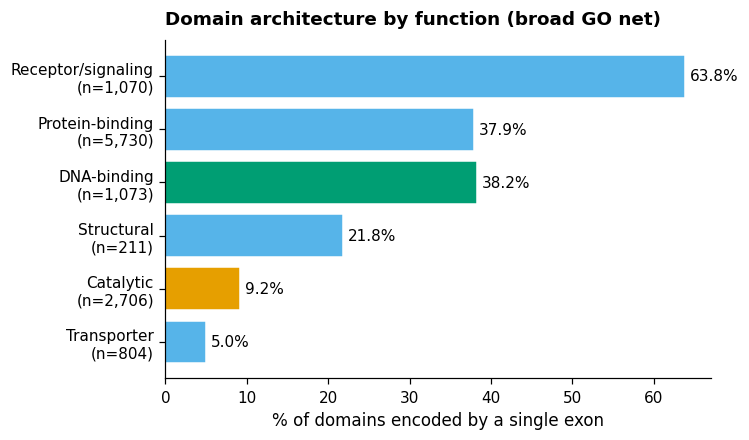

In [6]:
order = ["Receptor/signaling", "Protein-binding", "DNA-binding",
         "Structural", "Catalytic", "Transporter"]
cs = (d[d.fclass.isin(order)].groupby("fclass")
        .agg(n=("input_id", "size"),
             single=("is_single_exon_domain", lambda s: 100*s.mean()),
             med_exons=("n_touched", "median"))
        .reindex(order))
print(cs.round(1).to_string())

fig, ax = plt.subplots(figsize=(6.4, 4))
cols = [COLORS['good'] if f == "DNA-binding" else
        (COLORS['transvar'] if f == "Catalytic" else COLORS['neutral'])
        for f in cs.index]
ax.barh(range(len(cs)), cs["single"], color=cols, edgecolor="white")
ax.set_yticks(range(len(cs)))
ax.set_yticklabels([f"{f}\n(n={int(n):,})" for f, n in zip(cs.index, cs.n)])
ax.invert_yaxis(); ax.grid(False)
ax.set_xlabel("% of domains encoded by a single exon")
ax.set_title("Domain architecture by function (broad GO net)", loc="left")
for i, v in enumerate(cs["single"]):
    ax.text(v + 0.6, i, f"{v:.1f}%", va="center", fontsize=10)
from IPython.display import display
display(fig)
fig.savefig(DATA / "fig_analysis1_byclass.png", bbox_inches="tight")

## 6. Analysis #2 — position of the domain along the transcript

Position is only defined for **multi-exon transcripts** — a single-CDS-exon
transcript has no 5′/3′ axis — so those are excluded here. Domains span the whole
transcript with a **mild 3′ lean** (median ~0.54; more domains fall in the 3′
third than the 5′ third).

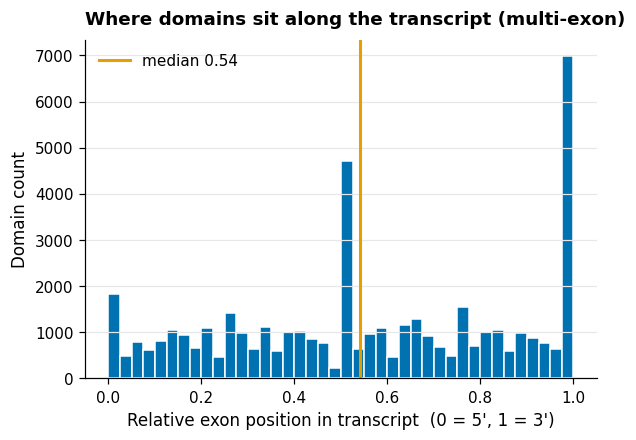

44,924 domains in multi-exon transcripts (3,288 single-exon transcripts excluded)
5'-third 26.3% | middle 35.2% | 3'-third 38.5%


In [7]:
pos = d[d["n_cds_exons"] > 1]   # 5'/3' position undefined for single-exon transcripts
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(pos.rel_exon_position, bins=40, color=COLORS['prot2exon'], edgecolor="white")
ax.axvline(pos.rel_exon_position.median(), color=COLORS['transvar'], lw=2,
           label=f"median {pos.rel_exon_position.median():.2f}")
ax.set_xlabel("Relative exon position in transcript  (0 = 5', 1 = 3')")
ax.set_ylabel("Domain count")
ax.set_title("Where domains sit along the transcript (multi-exon)", loc="left")
ax.legend()
display(fig)
fig.savefig(DATA / "fig_analysis2_position.png", bbox_inches="tight")
print(f"{len(pos):,} domains in multi-exon transcripts "
      f"({len(d)-len(pos):,} single-exon transcripts excluded)")
print("5'-third %.1f%% | middle %.1f%% | 3'-third %.1f%%" % (
    100*(pos.rel_exon_position < 1/3).mean(),
    100*((pos.rel_exon_position >= 1/3) & (pos.rel_exon_position <= 2/3)).mean(),
    100*(pos.rel_exon_position > 2/3).mean()))

## 7. Analysis #3 — completeness

Multi-exon domains use most of the nucleotides of the exons they span
(the exons are "about" that domain). Single-exon domains have **lower**
completeness — a compact domain often sits inside a much larger exon that codes
far more than the domain itself.

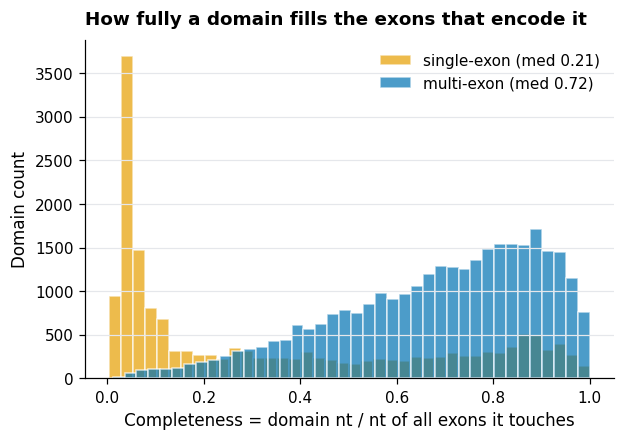

median completeness overall 0.640


In [8]:
fig, ax = plt.subplots(figsize=(6.2, 4))
se = d[d.is_single_exon_domain].completeness
me = d[~d.is_single_exon_domain].completeness
ax.hist(se, bins=40, alpha=0.7, color=COLORS['transvar'], edgecolor="white",
        label=f"single-exon (med {se.median():.2f})")
ax.hist(me, bins=40, alpha=0.7, color=COLORS['prot2exon'], edgecolor="white",
        label=f"multi-exon (med {me.median():.2f})")
ax.set_xlabel("Completeness = domain nt / nt of all exons it touches")
ax.set_ylabel("Domain count")
ax.set_title("How fully a domain fills the exons that encode it", loc="left")
ax.legend()
display(fig)
fig.savefig(DATA / "fig_analysis3_completeness.png", bbox_inches="tight")
print(f"median completeness overall {d.completeness.median():.3f}")